A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

In [3]:
import numpy as np

gas = "H2H2"

# import data
if gas == "O2O2":
    DATA = "datasets/O2O2_collisions.csv"
elif gas == "H2H2":
    DATA = "datasets/H2H2_collisions.csv"
rawdata = np.loadtxt(DATA, delimiter=',', skiprows=1)

# Make train/validation split
train_size = int(0.7 * rawdata.shape[0])
val_size = rawdata.shape[0] - train_size

# Convert to the variable set (Ec, \eta_trans, \eta_rot_A)
inputdata = np.zeros((rawdata.shape[0], 3))
inputdata[:,0] = np.sum(rawdata[:,0:3], axis=1)
inputdata[:,1] = rawdata[:,0]/inputdata[:,0] 
inputdata[:,2] = rawdata[:,1] / np.sum(rawdata[:,1:3], axis=1)

outputdata = np.zeros((rawdata.shape[0], 2))
outputdata[:,0] = rawdata[:,3]/np.sum(rawdata[:,3:6], axis=1)
outputdata[:,1] = rawdata[:,4]/ np.sum(rawdata[:,4:6], axis=1)


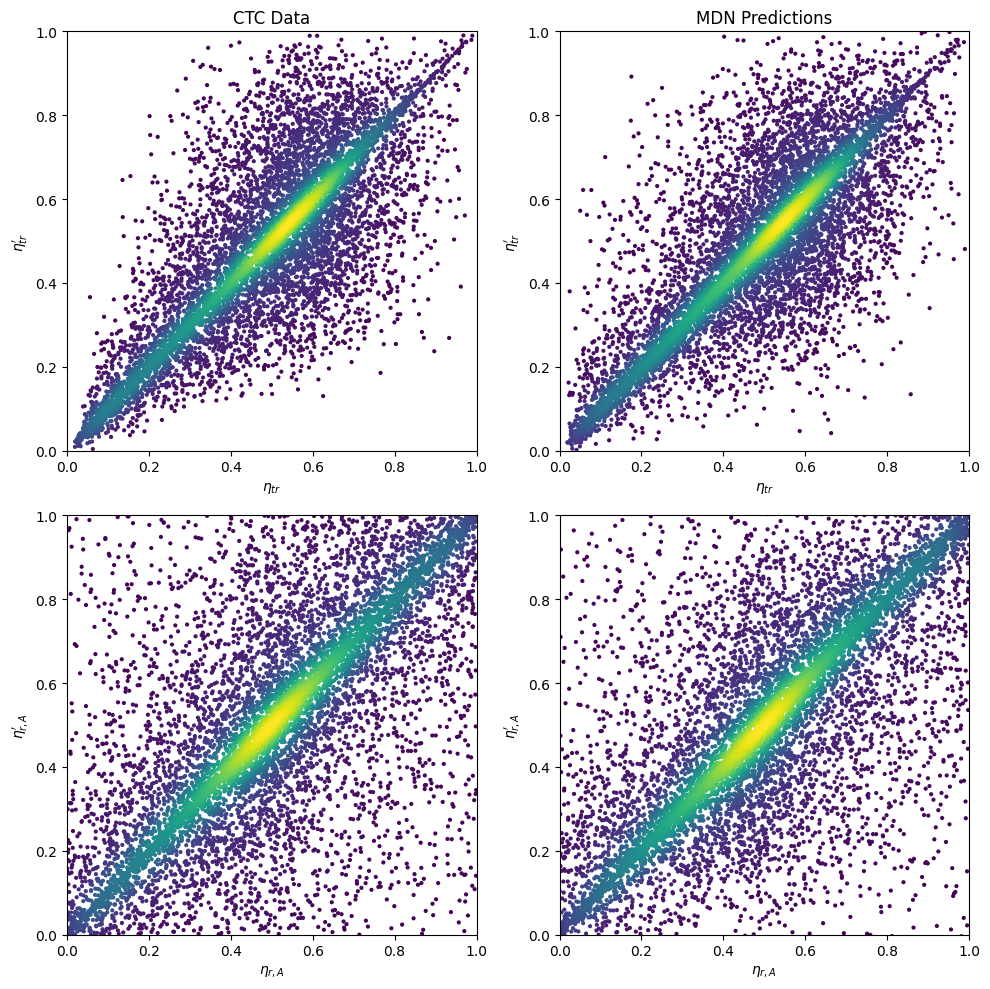

In [ ]:
import torch
import numpy as np
from mdn_utils import plot_scattering_comparison
from machinelearning.define_mdn import MixtureDensityNetwork

ckpt = torch.load("trainedmodels/mdn_h2h2_collision_model.pth", map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt)
K = state_dict["pi_layer.weight"].shape[0]

mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(state_dict)


# plot comparison
plot_scattering_comparison(
    np.column_stack((inputdata, outputdata)),
    mdn_model,
    in_mean=ckpt.get("in_mean"),
    in_std=ckpt.get("in_std"),
    out_mean=ckpt.get("out_mean"),
    out_std=ckpt.get("out_std"),
)
